# Phase 2 — Domain Gap Evaluation on ACDC

**Goal:** Run the Phase 1 model (zero retraining) on ACDC adverse-weather images
and measure the mIoU drop vs Cityscapes.

**Inputs needed in this Kaggle notebook:**
- `ripperworld/acdc-full-dataset` (add both Version 1 images + Version 2 masks)
- Your Phase 1 notebook output (contains `best_model.pth`)

**Conditions:** Fog | Rain | Snow | Night

In [1]:
!pip install segmentation-models-pytorch -q
print('Done')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 4.0 MB/s eta 0:00:0000:01
Done


In [2]:
import os, glob, random, warnings
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms.functional as TF
from PIL import Image
import matplotlib.pyplot as plt
import segmentation_models_pytorch as smp
from tqdm import tqdm

warnings.filterwarnings('ignore')

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')

Device: cuda


In [3]:
CFG = {
    'img_size'    : 512,
    'batch_size'  : 8,
    'num_classes' : 19,
    'ignore_index': 255,
}

# ── Phase 1 baseline result ──────────────────────────────────────
CITYSCAPES_MIOU = 73.18   # Phase 1 final TTA mIoU (%) — SegFormer/MiT-B4

MEAN = [0.485, 0.456, 0.406]
STD  = [0.229, 0.224, 0.225]

CLASS_NAMES = [
    'road','sidewalk','building','wall','fence','pole',
    'traffic light','traffic sign','vegetation','terrain','sky',
    'person','rider','car','truck','bus','train','motorcycle','bicycle'
]

CITYSCAPES_COLORS = [
    (128,64,128),(244,35,232),(70,70,70),(102,102,156),(190,153,153),
    (153,153,153),(250,170,30),(220,220,0),(107,142,35),(152,251,152),
    (70,130,180),(220,20,60),(255,0,0),(0,0,142),(0,0,70),
    (0,60,100),(0,80,100),(0,0,230),(119,11,32)
]

CONDITIONS = ['fog', 'rain', 'snow', 'night']
print('Config ready — Phase 1 baseline:', CITYSCAPES_MIOU, '%')

Config ready — Phase 1 baseline: 73.18 %


In [4]:
# Auto-search for best_model.pth across all Kaggle inputs
MODEL_PATH = None
for root, dirs, files in os.walk('/kaggle/input'):
    for f in files:
        if f == 'best_model.pth':
            MODEL_PATH = os.path.join(root, f)
            break
    if MODEL_PATH:
        break

# Also check working dir (if running Phase 1 and 2 in same session)
if MODEL_PATH is None and os.path.exists('/kaggle/working/best_model.pth'):
    MODEL_PATH = '/kaggle/working/best_model.pth'

if MODEL_PATH:
    size_mb = os.path.getsize(MODEL_PATH) / 1e6
    print(f'Model found : {MODEL_PATH}  ({size_mb:.1f} MB)')
else:
    raise FileNotFoundError(
        'best_model.pth not found!\n'
        'Add your Phase 1 notebook output as input:\n'
        '  Kaggle notebook → Add Input → Your Work → Phase 1 notebook → Add output'
    )

Model found : /kaggle/input/datasets/khushireddymacha/phase1-model/best_model.pth  (245.8 MB)


In [5]:
# Find ACDC root
ACDC_ROOT = None
for root, dirs, _ in os.walk('/kaggle/input'):
    if 'rgb_anon' in dirs:
        ACDC_ROOT = root
        break

if ACDC_ROOT is None:
    raise FileNotFoundError(
        'ACDC dataset not found!\n'
        'Add ripperworld/acdc-full-dataset (both versions) as input.'
    )

print(f'ACDC root: {ACDC_ROOT}')
print()

# Count available data per condition
for cond in CONDITIONS:
    for split in ['val', 'train']:
        imgs  = glob.glob(os.path.join(ACDC_ROOT,'rgb_anon',cond,split,'**','*.png'), recursive=True)
        masks = glob.glob(os.path.join(ACDC_ROOT,'gt',cond,split,'**','*_gt_labelTrainIds.png'), recursive=True)
        if imgs or masks:
            print(f'  {cond:6s}/{split:5s}: {len(imgs):4d} images | {len(masks):4d} masks')

ACDC root: /kaggle/input/datasets/khushireddymacha/acdc-dataset/rgb_anon_trainvaltest (2)/rgb_anon_trainvaltest

  fog   /val  :  100 images |    0 masks
  fog   /train:  400 images |    0 masks
  rain  /val  :  100 images |    0 masks
  rain  /train:  400 images |    0 masks
  snow  /val  :  100 images |    0 masks
  snow  /train:  400 images |    0 masks
  night /val  :  106 images |    0 masks
  night /train:  400 images |    0 masks


In [6]:
# Find actual rgb_anon and gt roots (handles nested folders)
RGB_ROOT = None
GT_ROOT  = None

for root, dirs, files in os.walk('/kaggle/input'):
    for d in dirs:
        full = os.path.join(root, d)
        if d == 'rgb_anon' and RGB_ROOT is None:
            # Check it actually has condition subfolders
            subs = os.listdir(full)
            if any(c in subs for c in ['fog','rain','snow','night']):
                RGB_ROOT = full
        if d == 'gt' and GT_ROOT is None:
            subs = os.listdir(full)
            if any(c in subs for c in ['fog','rain','snow','night']):
                GT_ROOT = full

print(f'RGB root : {RGB_ROOT}')
print(f'GT  root : {GT_ROOT}')

RGB root : /kaggle/input/datasets/khushireddymacha/acdc-dataset/rgb_anon_trainvaltest (2)/rgb_anon_trainvaltest/rgb_anon
GT  root : /kaggle/input/datasets/khushireddymacha/acdc-dataset/gt


In [7]:
class ACDCDataset(Dataset):
    """
    Pairs ACDC images with gt_labelTrainIds masks.
    Image : rgb_anon/{cond}/{split}/**/*_rgb_anon.png
    Mask  : gt/{cond}/{split}/**/*_gt_labelTrainIds.png
    """
    def __init__(self, acdc_root, condition, img_size=512):
        self.img_size = img_size
        self.pairs = []

        for split in ['val', 'train']:
            img_dir  = os.path.join(RGB_ROOT, condition, split)
            mask_dir = os.path.join(GT_ROOT,  condition, split)
            if not os.path.exists(img_dir):
                continue

            all_imgs  = sorted(glob.glob(
                os.path.join(img_dir,  '**', '*_rgb_anon.png'), recursive=True))
            all_masks = sorted(glob.glob(
                os.path.join(mask_dir, '**', '*_gt_labelTrainIds.png'), recursive=True))

            # Build mask lookup: frame_id -> mask_path
            mask_lookup = {}
            for m in all_masks:
                key = os.path.basename(m).replace('_gt_labelTrainIds.png', '')
                mask_lookup[key] = m

            for img_path in all_imgs:
                key = os.path.basename(img_path).replace('_rgb_anon.png', '')
                if key in mask_lookup:
                    self.pairs.append((img_path, mask_lookup[key]))

        print(f'  ACDC {condition}: {len(self.pairs)} paired samples')

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        img_path, mask_path = self.pairs[idx]

        img = Image.open(img_path).convert('RGB')
        img = img.resize((self.img_size, self.img_size), Image.BILINEAR)
        img_t = TF.normalize(TF.to_tensor(img), mean=MEAN, std=STD)

        lbl = Image.open(mask_path)
        lbl = lbl.resize((self.img_size, self.img_size), Image.NEAREST)
        lbl_arr = np.array(lbl, dtype=np.uint8)
        if lbl_arr.ndim == 3:
            lbl_arr = lbl_arr[:, :, 0]
        lbl_t = torch.from_numpy(lbl_arr).long()

        return img_t, lbl_t, img_path

print('ACDCDataset class ready')

ACDCDataset class ready


In [8]:
model = smp.Segformer(
    encoder_name    = 'mit_b4',
    encoder_weights = None,
    in_channels     = 3,
    classes         = CFG['num_classes'],
)
model.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE))
model = model.to(DEVICE).eval()
print(f'Model loaded from: {MODEL_PATH}')
print('Ready for evaluation — no retraining')

Model loaded from: /kaggle/input/datasets/khushireddymacha/phase1-model/best_model.pth
Ready for evaluation — no retraining


In [9]:
def compute_miou(preds_np, labels_np, num_classes=19, ignore_index=255):
    iou_list  = []
    per_class = {}
    for cls in range(num_classes):
        ignore = (labels_np == ignore_index)
        pm = (preds_np  == cls) & ~ignore
        tm = (labels_np == cls) & ~ignore
        inter = (pm & tm).sum()
        union = (pm | tm).sum()
        if union == 0:
            per_class[cls] = float('nan')
            continue
        iou = float(inter) / float(union)
        per_class[cls] = iou
        iou_list.append(iou)
    miou = float(np.mean(iou_list)) if iou_list else 0.0
    return miou, per_class

print('mIoU function ready')

mIoU function ready


In [10]:
results = {}   # condition -> {miou, per_class, n_samples}

for cond in CONDITIONS:
    print(f'\nEvaluating: {cond.upper()}')
    try:
        ds = ACDCDataset(ACDC_ROOT, cond, img_size=CFG['img_size'])
        if len(ds) == 0:
            print(f'  No data found for {cond} — skipping')
            continue
    except Exception as e:
        print(f'  Error: {e} — skipping')
        continue

    loader = DataLoader(ds, batch_size=CFG['batch_size'],
                        shuffle=False, num_workers=0)

    all_preds, all_lbls = [], []
    with torch.no_grad():
        for imgs, lbls, _ in tqdm(loader, desc=f'  {cond}'):
            preds = model(imgs.to(DEVICE)).argmax(1).cpu().numpy()
            all_preds.append(preds)
            all_lbls.append(lbls.numpy())

    all_preds = np.concatenate(all_preds)
    all_lbls  = np.concatenate(all_lbls)
    miou, per_class = compute_miou(all_preds, all_lbls)

    results[cond] = {
        'miou'     : miou,
        'per_class': per_class,
        'n_samples': len(ds),
        'preds'    : all_preds,
        'lbls'     : all_lbls,
        'ds'       : ds,
    }
    print(f'  --> {cond.upper()} mIoU: {miou*100:.2f}%')

print('\n=== Evaluation complete ===')


Evaluating: FOG
  ACDC fog: 500 paired samples


  fog: 100%|██████████| 63/63 [01:16<00:00,  1.22s/it]


  --> FOG mIoU: 60.73%

Evaluating: RAIN
  ACDC rain: 500 paired samples


  rain: 100%|██████████| 63/63 [01:17<00:00,  1.23s/it]


  --> RAIN mIoU: 52.37%

Evaluating: SNOW
  ACDC snow: 500 paired samples


  snow: 100%|██████████| 63/63 [01:22<00:00,  1.30s/it]


  --> SNOW mIoU: 47.62%

Evaluating: NIGHT
  ACDC night: 506 paired samples


  night: 100%|██████████| 64/64 [01:19<00:00,  1.25s/it]


  --> NIGHT mIoU: 35.35%

=== Evaluation complete ===


In [11]:
print('=' * 58)
print(f'  {"Domain":<22} {"mIoU":>8}   {"vs Cityscapes":>15}')
print('-' * 58)
print(f'  {"Cityscapes (Source)":<22} {CITYSCAPES_MIOU:>7.2f}%   {"(baseline)":>15}')
print('-' * 58)
for cond, r in results.items():
    drop = r['miou']*100 - CITYSCAPES_MIOU
    print(f'  {"ACDC " + cond.capitalize():<22} {r["miou"]*100:>7.2f}%   {drop:>+14.2f}%')
if results:
    avg  = np.mean([r['miou']*100 for r in results.values()])
    drop = avg - CITYSCAPES_MIOU
    print('-' * 58)
    print(f'  {"ACDC Average":<22} {avg:>7.2f}%   {drop:>+14.2f}%')
print('=' * 58)

  Domain                     mIoU     vs Cityscapes
----------------------------------------------------------
  Cityscapes (Source)      73.18%        (baseline)
----------------------------------------------------------
  ACDC Fog                 60.73%           -12.45%
  ACDC Rain                52.37%           -20.81%
  ACDC Snow                47.62%           -25.56%
  ACDC Night               35.35%           -37.83%
----------------------------------------------------------
  ACDC Average             49.02%           -24.16%


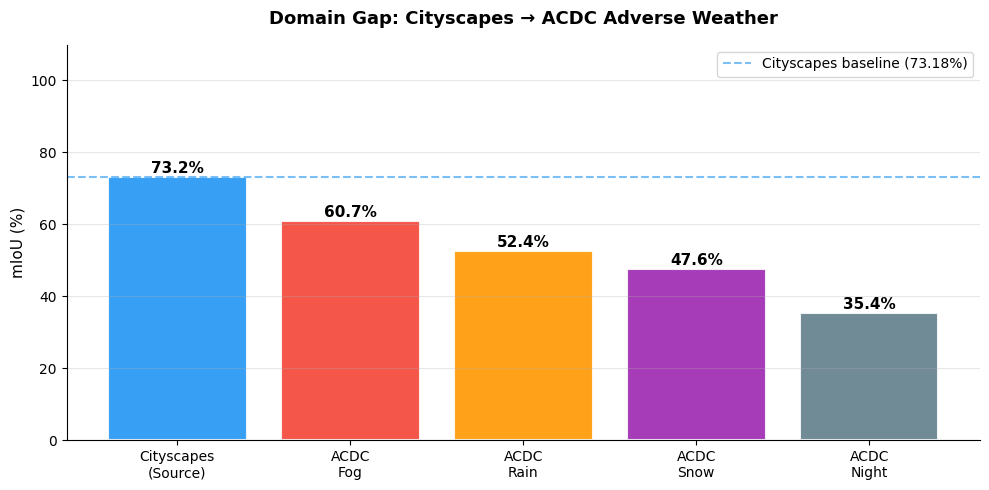

In [12]:
labels_plot = ['Cityscapes\n(Source)'] + \
              [f'ACDC\n{c.capitalize()}' for c in results.keys()]
values_plot = [CITYSCAPES_MIOU] + [r['miou']*100 for r in results.values()]
bar_colors  = ['#2196F3','#F44336','#FF9800','#9C27B0','#607D8B']

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(labels_plot, values_plot,
              color=bar_colors[:len(labels_plot)],
              edgecolor='white', linewidth=1.5, alpha=0.9)

ax.axhline(y=CITYSCAPES_MIOU, color='#2196F3',
           linestyle='--', linewidth=1.5, alpha=0.6,
           label=f'Cityscapes baseline ({CITYSCAPES_MIOU}%)')

for bar, val in zip(bars, values_plot):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.3,
            f'{val:.1f}%', ha='center', va='bottom',
            fontsize=11, fontweight='bold')

ax.set_title('Domain Gap: Cityscapes → ACDC Adverse Weather',
             fontsize=13, fontweight='bold', pad=15)
ax.set_ylabel('mIoU (%)', fontsize=11)
ax.set_ylim(0, CITYSCAPES_MIOU * 1.5)
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('/kaggle/working/domain_gap_chart.png', dpi=150, bbox_inches='tight')
plt.show()

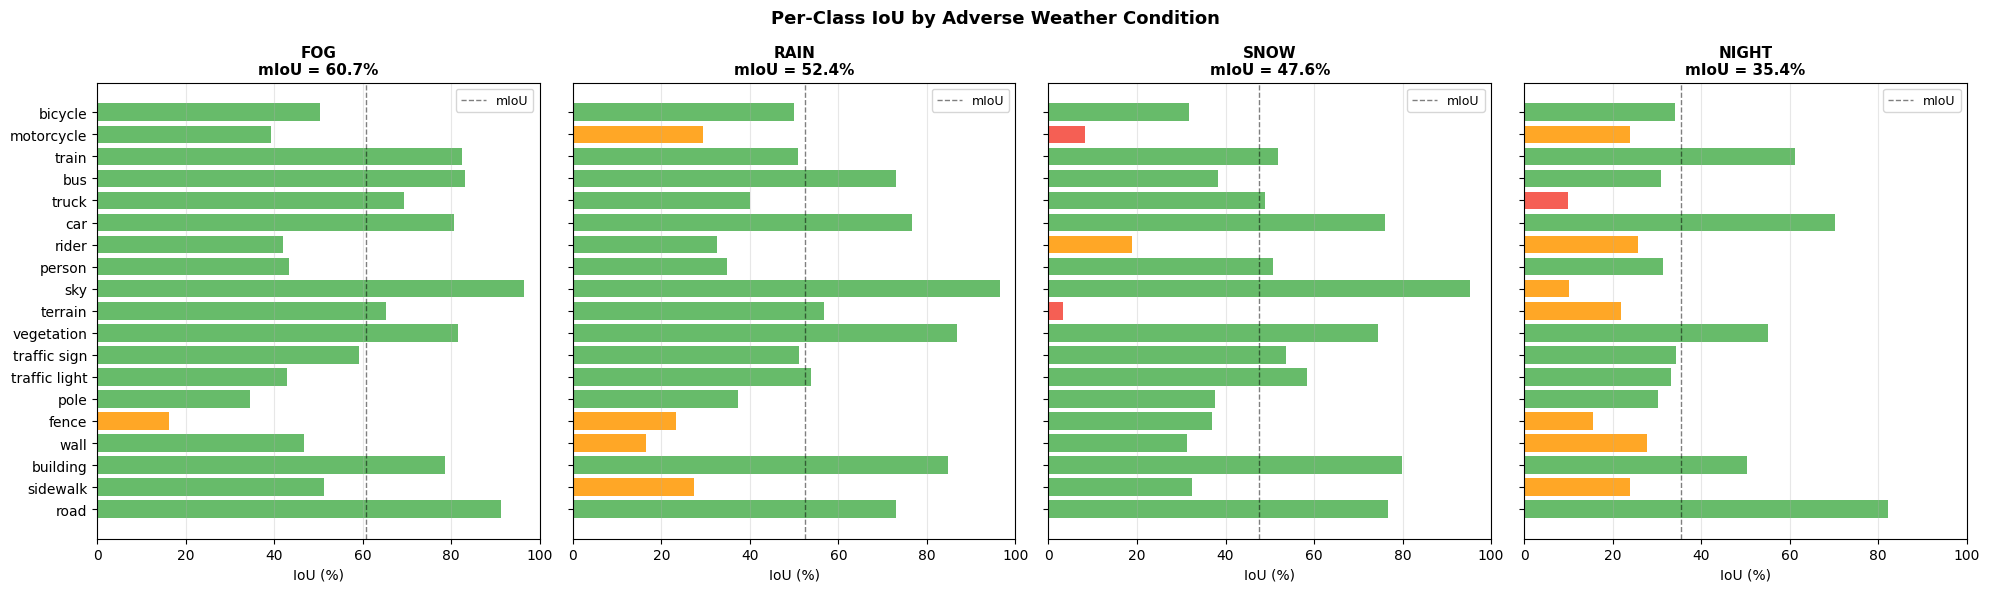

In [13]:
if results:
    cond_list = list(results.keys())
    n = len(cond_list)
    fig, axes = plt.subplots(1, n, figsize=(5*n, 6), sharey=True)
    if n == 1: axes = [axes]
    fig.suptitle('Per-Class IoU by Adverse Weather Condition',
                 fontsize=13, fontweight='bold')

    for ax, cond in zip(axes, cond_list):
        pc   = results[cond]['per_class']
        vals = [pc.get(c, 0)*100 if not np.isnan(pc.get(c,float('nan'))) else 0
                for c in range(19)]
        clrs = ['#4CAF50' if v>30 else '#FF9800' if v>10 else '#F44336'
                for v in vals]
        ax.barh(CLASS_NAMES, vals, color=clrs, alpha=0.85)
        ax.axvline(x=results[cond]['miou']*100, color='black',
                   linestyle='--', linewidth=1, alpha=0.5, label='mIoU')
        ax.set_title(f'{cond.upper()}\nmIoU = {results[cond]["miou"]*100:.1f}%',
                     fontsize=11, fontweight='bold')
        ax.set_xlabel('IoU (%)')
        ax.set_xlim(0, 100)
        ax.legend(fontsize=9)
        ax.grid(axis='x', alpha=0.3)

    plt.tight_layout()
    plt.savefig('/kaggle/working/per_class_iou.png', dpi=150, bbox_inches='tight')
    plt.show()

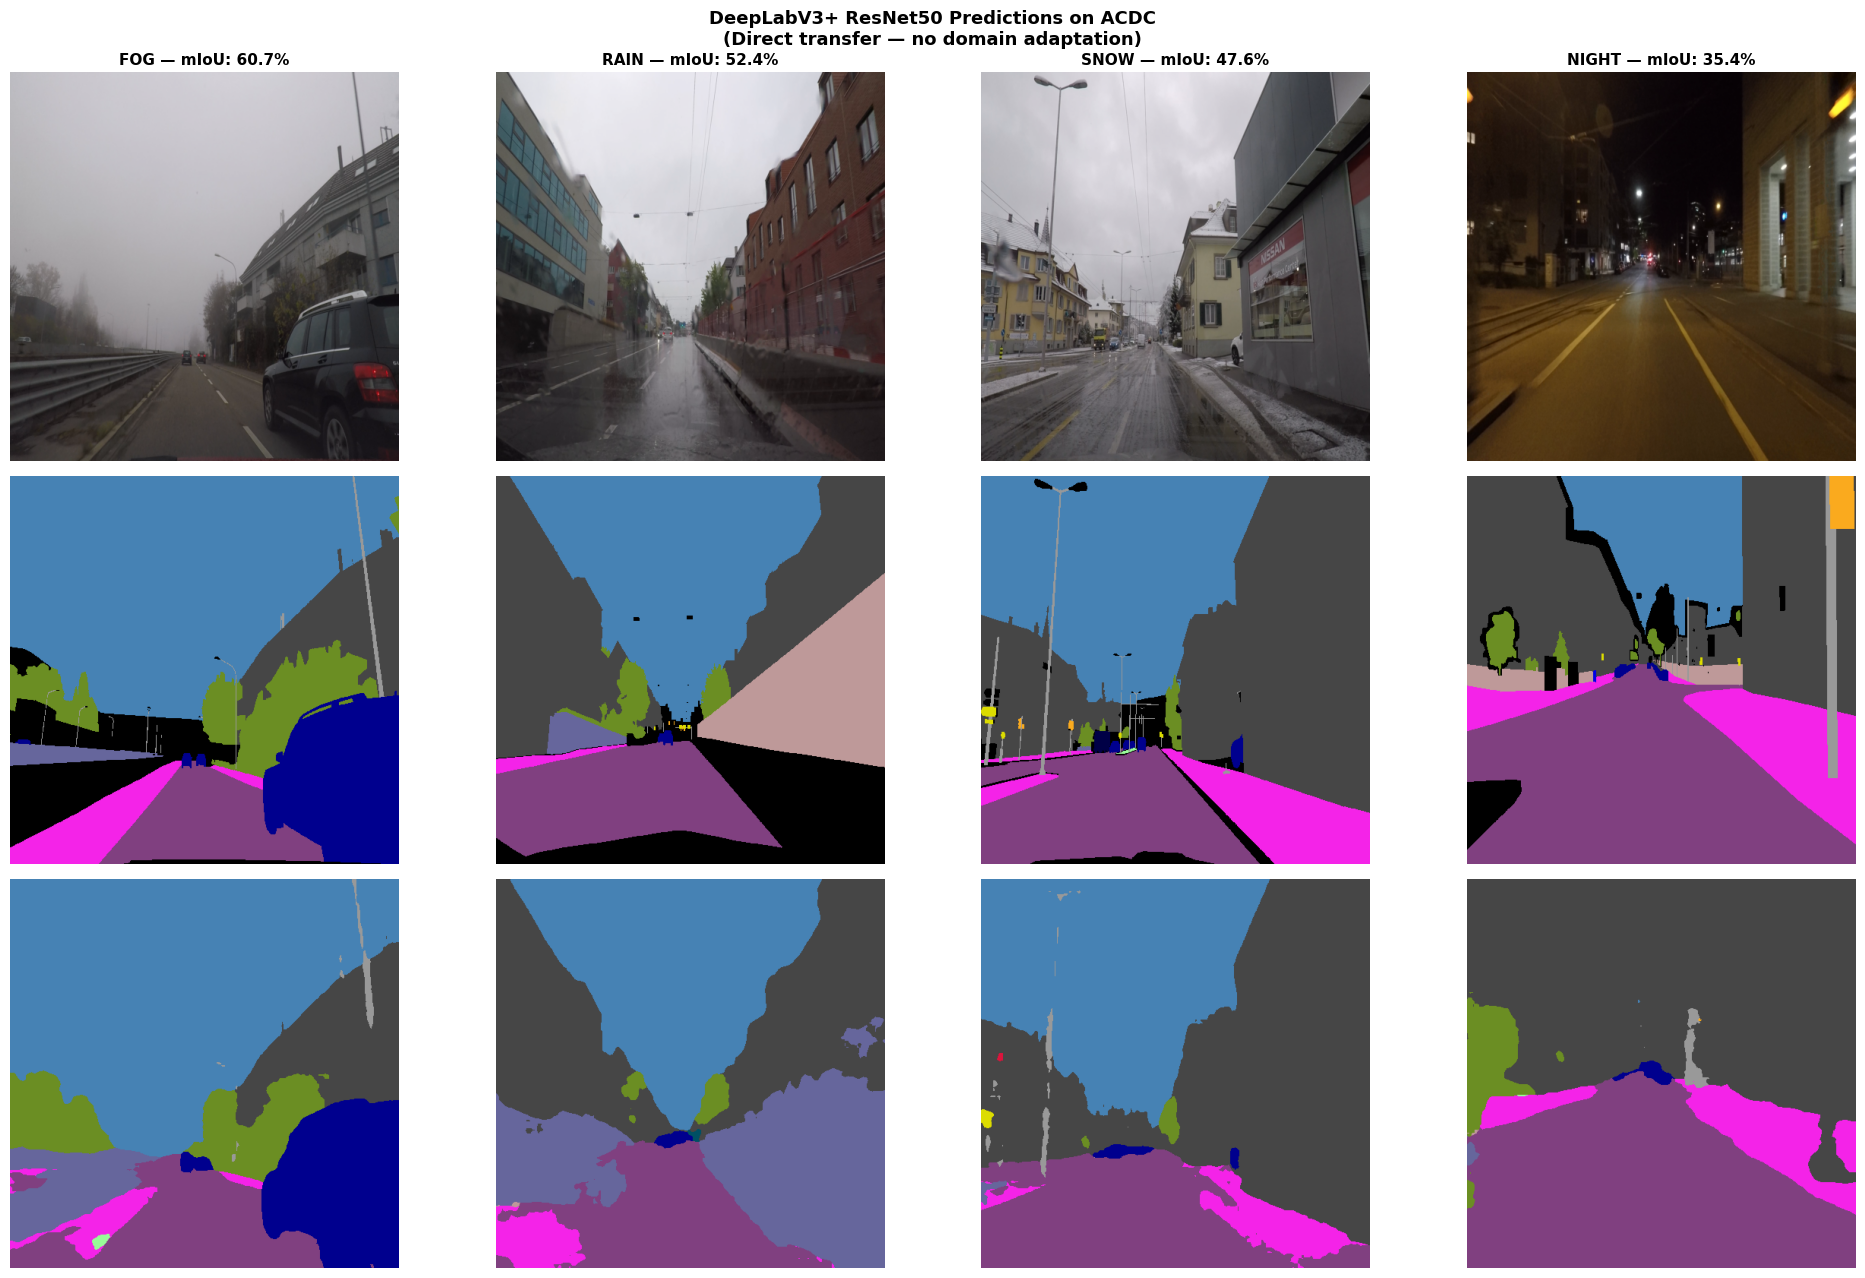

In [14]:
def colorize(mask):
    out = np.zeros((*mask.shape, 3), dtype=np.uint8)
    for i, c in enumerate(CITYSCAPES_COLORS):
        out[mask == i] = c
    return out

n_cond = len(results)
if n_cond == 0:
    print('No results to visualize')
else:
    fig, axes = plt.subplots(3, n_cond, figsize=(5*n_cond, 13))
    if n_cond == 1: axes = [[r] for r in axes]
    fig.suptitle(
        'DeepLabV3+ ResNet50 Predictions on ACDC\n'
        '(Direct transfer — no domain adaptation)',
        fontsize=13, fontweight='bold')

    for row, lbl in enumerate(['Input Image', 'Ground Truth', 'Prediction']):
        axes[row][0].set_ylabel(lbl, fontsize=11, fontweight='bold')

    for col, cond in enumerate(results.keys()):
        ds  = results[cond]['ds']
        idx = random.randint(0, len(ds)-1)
        img_t, lbl_t, _ = ds[idx]

        with torch.no_grad():
            pred = model(img_t.unsqueeze(0).to(DEVICE)) \
                       .argmax(1).squeeze(0).cpu().numpy()

        img_np = np.clip(
            img_t.permute(1,2,0).numpy() * np.array(STD) + np.array(MEAN),
            0, 1)

        axes[0][col].imshow(img_np)
        axes[0][col].set_title(
            f'{cond.upper()} — mIoU: {results[cond]["miou"]*100:.1f}%',
            fontsize=11, fontweight='bold')
        axes[1][col].imshow(colorize(lbl_t.numpy()))
        axes[2][col].imshow(colorize(pred))
        for row in range(3): axes[row][col].axis('off')

    plt.tight_layout()
    plt.savefig('/kaggle/working/acdc_predictions.png', dpi=150, bbox_inches='tight')
    plt.show()

In [15]:
print('=' * 58)
print('  PHASE 2 SUMMARY — DOMAIN GAP ANALYSIS')
print('=' * 58)
print(f'  Model         : SegFormer / MiT-B4 (Phase 1 trained)')
print(f'  Source domain : Cityscapes (clear weather)')
print(f'  Source mIoU   : {CITYSCAPES_MIOU:.2f}%')
print()
if results:
    avg  = np.mean([r['miou']*100 for r in results.values()])
    drop = CITYSCAPES_MIOU - avg
    pct  = drop / CITYSCAPES_MIOU * 100
    print(f'  ACDC avg mIoU : {avg:.2f}%')
    print(f'  Domain gap    : -{drop:.2f}% absolute drop')
    print(f'  Relative drop : {pct:.1f}% performance loss')
    print()
    print('  Per-condition:')
    for cond, r in results.items():
        print(f'    {cond.capitalize():<8}: {r["miou"]*100:.2f}%')
    print()
    print('  Conclusion: significant domain gap confirmed.')
    print('  Phase 3 (DAFormer) will use UDA to close this gap.')
print('=' * 58)

  PHASE 2 SUMMARY — DOMAIN GAP ANALYSIS
  Model         : SegFormer / MiT-B4 (Phase 1 trained)
  Source domain : Cityscapes (clear weather)
  Source mIoU   : 73.18%

  ACDC avg mIoU : 49.02%
  Domain gap    : -24.16% absolute drop
  Relative drop : 33.0% performance loss

  Per-condition:
    Fog     : 60.73%
    Rain    : 52.37%
    Snow    : 47.62%
    Night   : 35.35%

  Conclusion: significant domain gap confirmed.
  Phase 3 (DAFormer) will use UDA to close this gap.
